In [1]:
"""501b_inference_with_a_robotic_arm.ipynb."""

# Anomalib imports
from __future__ import annotations

import sys
import time  # time library
from datetime import datetime
from pathlib import Path
from threading import Thread
from typing import TYPE_CHECKING

if TYPE_CHECKING:
    import numpy as np

# importing required libraries
import cv2  # OpenCV library

from anomalib.deploy import OpenVINOInferencer

In [2]:
# Prepare the path to the datasets and the weights
dataset_path = Path.cwd() / "cubes"
weights_path = Path.cwd() / "weights"

In [3]:
def create_filename(path: Path) -> str:
    """Create the filename for new data(images).

    Args:
        path (Path): Initial path to save new images and results.

    Returns:
        str: Captured image filename
    """
    path.mkdir(exist_ok=True, parents=True)
    now = datetime.now().strftime("%Y%m%d%H%M%S")
    return str(path / f"input_{now}.jpg")

In [4]:
from anomalib import TaskType
# Acquisition mode
acquisition = False  # True False
source = 0  # number of the camera you want to use
folder = "abnormal"  # normal or abnormal

# If acquisition is False this notebook will work in inference mode
if acquisition is False:
    # If you are running inference check where the OpenVINO model is stored
    openvino_model_path = weights_path / "openvino" / "model.bin"
    metadata_path = weights_path / "openvino" / "metadata.json"

    print("OpenVINO model exist: ", openvino_model_path.exists())
    print("OpenVINO path: ", openvino_model_path)
    print("Metadata model exist: ", metadata_path.exists())
    print("Metadata path: ", metadata_path)

    inferencer = OpenVINOInferencer(
        path=openvino_model_path,  # Path to the OpenVINO IR model.
        metadata=metadata_path,  # Path to the metadata file.
        device="CPU",  # We would like to run it on an Intel CPU.
        task=TaskType.SEGMENTATION
    )

    if dataset_path.exists() is False:
        print("Make sure you have the dataset in a proper folder or it i already created")
else:
    dataset_path.mkdir(parents=True, exist_ok=True)

OpenVINO model exist:  True
OpenVINO path:  /Users/peterdesousa/projects/ml-experiments/anomalib/weights/openvino/model.bin
Metadata model exist:  True
Metadata path:  /Users/peterdesousa/projects/ml-experiments/anomalib/weights/openvino/metadata.json


In [20]:
image = cv2.imread("./datasets/gears/abnormal/0001.jpg")
result = inferencer.predict(image=image)
print(predictions.pred_score)

0.48978667489214806


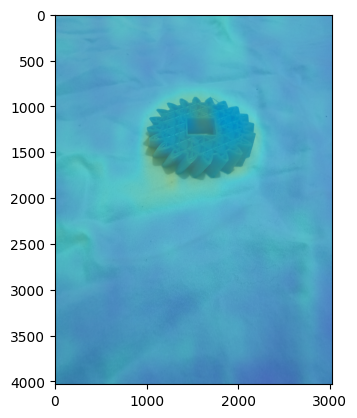

In [21]:
from matplotlib import pyplot as plt

plt.imshow(result.heat_map)
# plt.imshow(result.gt_mask)
# plt.imshow(result.pred_mask)